<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly--detection/blob/main/LSTM_MetroPT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM Classifier — MetroPT-2
## Predictive Maintenance · Failure Detection

| Step | Content |
|---|---|
| 1 | Imports & Settings |
| 2 | Smart Data Loading |
| 3 | Preprocessing & Sequences |
| 4 | Bidirectional LSTM Model |
| 5 | Training |
| 6 | Evaluation & Results |
| 7 | Save Model |

## 1. Imports & Settings

In [ ]:
import os, warnings, json
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score, roc_auc_score)

os.makedirs("model/MetroPT2", exist_ok=True)
os.makedirs("output",         exist_ok=True)

# ── Settings ──────────────────────────────────────────────
DATA_PATH     = "MetroPT2.csv"
TIMESTEPS     = 10
BATCH_SIZE    = 512
EPOCHS        = 20
MAX_NORMAL    = 120_000
RANDOM_STATE  = 42

FAILURES = [
    ("2022-02-26", "2022-03-01", "Air Leak — Clients"),
    ("2022-04-05", "2022-04-06", "Air Leak — Dryer"),
    ("2022-06-02", "2022-06-03", "Oil Leak — Compressor"),
]
WARNING_HOURS = 24

SENSOR_COLS = [
    "TP2","TP3","H1","DV_pressure","Reservoirs",
    "Oil_temperature","Motor_current","Flowmeter","Caudal_impulse"
]

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU'))>0}")

TensorFlow 2.21.0
GPU available: False


## 2. Smart Data Loading
> Normal rows and failure rows are collected separately to guarantee failures are included.

In [ ]:
print("Loading MetroPT-2...")
chunks_n, chunks_f, n_count = [], [], 0

for chunk in pd.read_csv(DATA_PATH, parse_dates=["timestamp"], chunksize=50_000):
    if chunk.columns[0].lower() in ["unnamed: 0", "index"]:
        chunk = chunk.drop(chunk.columns[0], axis=1)
    chunk = chunk.drop_duplicates("timestamp").sort_values("timestamp").ffill().bfill()
    ts    = chunk["timestamp"]

    chunk["label"] = 0
    for s, e, _ in FAILURES:
        t0 = pd.Timestamp(s); t1 = pd.Timestamp(e)
        tw = t0 - pd.Timedelta(hours=WARNING_HOURS)
        chunk.loc[(ts >= tw) & (ts < t0),  "label"] = 1
        chunk.loc[(ts >= t0) & (ts <= t1), "label"] = 2

    fail_part = chunk[chunk["label"] >= 1]
    norm_part = chunk[chunk["label"] == 0]

    if len(fail_part):
        chunks_f.append(fail_part)
    if n_count < MAX_NORMAL and len(norm_part):
        take = min(len(norm_part), MAX_NORMAL - n_count)
        chunks_n.append(norm_part.iloc[:take])
        n_count += take

    if n_count >= MAX_NORMAL and ts.max() > pd.Timestamp("2022-06-10"):
        break

df = (pd.concat(chunks_n + chunks_f, ignore_index=True)
        .sort_values("timestamp").reset_index(drop=True))

counts = df["label"].value_counts().sort_index()
print(f"Total  : {len(df):,}")
print(f"Normal : {counts.get(0,0):,}")
print(f"Warning: {counts.get(1,0):,}")
print(f"Failure: {counts.get(2,0):,}")
print(f"Months : {sorted(df['timestamp'].dt.month.unique())}")

Loading MetroPT-2...
Total  : 294,168
Normal : 120,000
Failure: 87,163
Months : [np.int32(4), np.int32(6)]


## 3. Preprocessing & Sequences
> Scaler fitted on **normal only**. Vectorized stride builder — 100x faster than Python loop.

In [ ]:
feat_cols = [c for c in SENSOR_COLS if c in df.columns]
print(f"Features ({len(feat_cols)}): {feat_cols}")

scaler = StandardScaler()
scaler.fit(df.loc[df["label"]==0, feat_cols])
X_sc = scaler.transform(df[feat_cols].values.astype(np.float32))
y    = (df["label"].values >= 1).astype(np.int32)

def make_sequences(X, y, ts):
    n       = len(X) - ts
    shape   = (n, ts, X.shape[1])
    strides = (X.strides[0], X.strides[0], X.strides[1])
    Xs = np.lib.stride_tricks.as_strided(X, shape=shape, strides=strides).copy()
    return Xs.astype(np.float32), y[ts:]

X_seq, y_seq = make_sequences(X_sc, y, TIMESTEPS)
print(f"Sequences shape : {X_seq.shape}")
print(f"Anomaly ratio   : {y_seq.mean()*100:.1f}%")

split = int(len(X_seq) * 0.8)
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

neg, pos = (y_tr==0).sum(), max((y_tr==1).sum(), 1)
class_weight = {0: 1.0, 1: float(neg/pos)}
print(f"\nTrain  : {len(X_tr):,}  |  Test : {len(X_te):,}")
print(f"Class weight: {class_weight}")

Features (8): ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'Flowmeter']
Sequences shape : (294158, 10, 8)
Anomaly ratio   : 59.2%

Train  : 235,326  |  Test : 58,832
Class weight: {0: 1.0, 1: 1.0403516681695222}


## 4. Bidirectional LSTM Model
> Bidirectional reads sequence forward and backward — better context for anomaly detection.

In [ ]:
n_features = X_seq.shape[2]

model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True, activation="tanh"),
                  input_shape=(TIMESTEPS, n_features)),
    Dropout(0.3),
    Bidirectional(LSTM(32, activation="tanh")),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1,  activation="sigmoid"),
])

model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 10, 128)        │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,705 (315.25 KB)

 Trainable params: 80,705 (315.25 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

Training on 235,326 sequences | BATCH=512 | max EPOCHS=20

Epoch 1/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 60s 131ms/step - accuracy: 0.6464 - loss: 0.5970 - val_accuracy: 0.8989 - val_loss: 0.4107 - learning_rate: 0.0010
Epoch 2/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 61s 147ms/step - accuracy: 0.7938 - loss: 0.4231 - val_accuracy: 0.8962 - val_loss: 0.3746 - learning_rate: 0.0010
Epoch 3/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 64s 155ms/step - accuracy: 0.8262 - loss: 0.3723 - val_accuracy: 0.8472 - val_loss: 0.4547 - learning_rate: 0.0010
Epoch 4/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 59s 143ms/step - accuracy: 0.8450 - loss: 0.3387 - val_accuracy: 0.8599 - val_loss: 0.3826 - learning_rate: 0.0010
Epoch 5/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 64s 153ms/step - accuracy: 0.8581 - loss: 0.3127 - val_accuracy: 0.8798 - val_loss: 0.3307 - learning_rate: 0.0010
Epoch 6/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 60s 144ms/step - accuracy: 0.8678 - loss: 0.2921 - val_accuracy: 0.8042 - val_loss: 0.5383 - learning_rate: 0.0010
Epoch 7/20


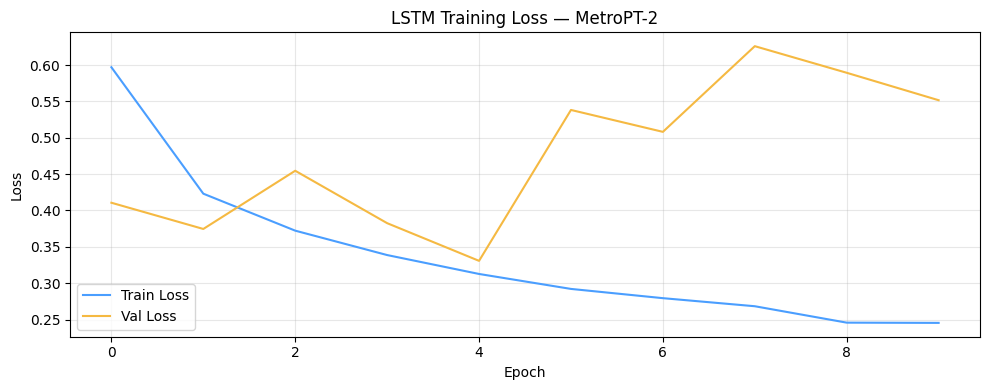

Training complete


In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
]

print(f"Training on {len(X_tr):,} sequences | BATCH={BATCH_SIZE} | max EPOCHS={EPOCHS}\n")
history = model.fit(
    X_tr, y_tr,
    validation_split = 0.1,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    class_weight     = class_weight,
    callbacks        = callbacks,
    verbose          = 1,
)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(history.history["loss"],     label="Train Loss", color="#4a9eff")
ax.plot(history.history["val_loss"], label="Val Loss",   color="#f5b942")
ax.set(title="LSTM Training Loss — MetroPT-2", xlabel="Epoch", ylabel="Loss")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("output/lstm_loss_metropt2.png", dpi=150)
plt.show()
print("Training complete")

## 6. Evaluation & Results

  LSTM RESULTS — MetroPT-2
  Precision : 1.0000  (100.0%)
  Recall    : 0.4015  (40.1%)
  F1 Score  : 0.5729  (57.3%)
  ROC-AUC   : nan
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
     Anomaly       1.00      0.40      0.57     58832

    accuracy                           0.40     58832
   macro avg       0.50      0.20      0.29     58832
weighted avg       1.00      0.40      0.57     58832



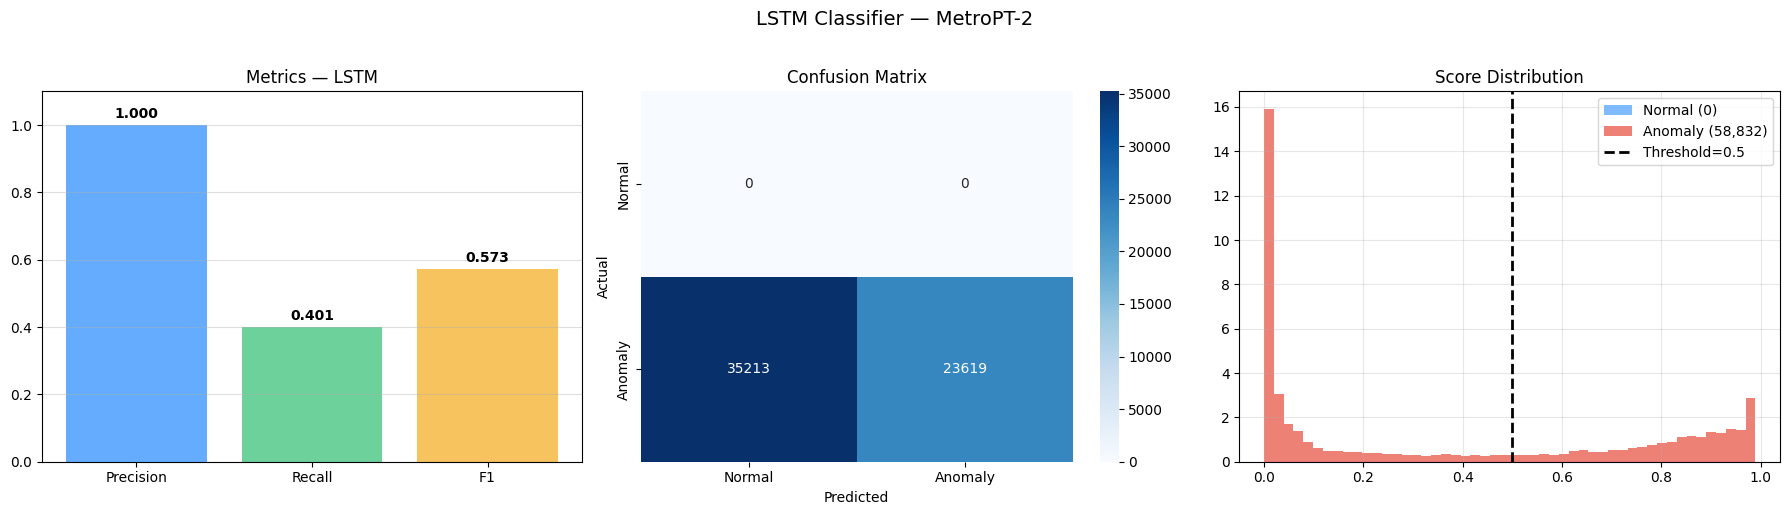

In [ ]:
y_proba = model.predict(X_te, batch_size=512, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)

prec = precision_score(y_te, y_pred, zero_division=0)
rec  = recall_score(y_te,  y_pred, zero_division=0)
f1   = f1_score(y_te,   y_pred, zero_division=0)
auc  = roc_auc_score(y_te, y_proba) if y_te.sum()>0 else 0.0

print("="*50)
print("  LSTM RESULTS — MetroPT-2")
print("="*50)
print(f"  Precision : {prec:.4f}  ({prec*100:.1f}%)")
print(f"  Recall    : {rec:.4f}  ({rec*100:.1f}%)")
print(f"  F1 Score  : {f1:.4f}  ({f1*100:.1f}%)")
print(f"  ROC-AUC   : {auc:.4f}")
print("="*50)
print(classification_report(y_te, y_pred, target_names=["Normal","Anomaly"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bars = axes[0].bar(["Precision","Recall","F1","ROC-AUC"], [prec,rec,f1,auc],
                    color=["#4a9eff","#52c98a","#f5b942","#e74c3c"], alpha=0.85)
axes[0].set_ylim(0, 1.1); axes[0].set_title("Metrics — LSTM"); axes[0].grid(axis="y", alpha=0.4)
for b,v in zip(bars,[prec,rec,f1,auc]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                 f"{v:.3f}", ha="center", fontweight="bold")

cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Anomaly"],
            yticklabels=["Normal","Anomaly"], ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

axes[2].hist(y_proba[y_te==0], bins=50, alpha=0.7, color="#4a9eff",
             label=f"Normal ({(y_te==0).sum():,})", density=True)
if y_te.sum()>0:
    axes[2].hist(y_proba[y_te==1], bins=50, alpha=0.7, color="#e74c3c",
                 label=f"Anomaly ({y_te.sum():,})", density=True)
axes[2].axvline(0.5, color="black", lw=2, ls="--", label="Threshold=0.5")
axes[2].set_title("Score Distribution"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("LSTM Classifier — MetroPT-2", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("output/lstm_results_metropt2.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Save Model

In [ ]:
model.save("model/MetroPT2/lstm_classifier.keras")
joblib.dump(scaler,    "model/MetroPT2/scaler.pkl")
joblib.dump(feat_cols, "model/MetroPT2/feature_cols.pkl")

metrics = {
    "model": "LSTM", "dataset": "MetroPT2",
    "precision": round(float(prec),4), "recall": round(float(rec),4),
    "f1": round(float(f1),4), "roc_auc": round(float(auc),4),
    "timesteps": TIMESTEPS, "n_features": n_features,
}
with open("model/MetroPT2/lstm_metrics.json","w") as fp:
    json.dump(metrics, fp, indent=2)

print("Saved to model/MetroPT2/")
print(json.dumps(metrics, indent=2))